# llminfer README Walkthrough (Colab)

This notebook mirrors the README flow for `llminfer`: quick start, streaming, batching, prefix KV cache reuse, benchmarking, backend comparison, and CLI.

## 0) Runtime setup
In Colab, select **Runtime -> Change runtime type -> GPU** before running cells.

In [1]:
!nvidia-smi

Wed Feb 25 13:18:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import platform
import torch

print('Python:', platform.python_version())
print('Torch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
print('CUDA version:', torch.version.cuda)

if not torch.cuda.is_available():
    raise RuntimeError('GPU not available. Switch runtime to GPU and retry.')

Python: 3.12.12
Torch: 2.10.0+cu128
CUDA available: True
CUDA version: 12.8


## 1) Clone and install llminfer
Update `REPO_URL` to your repo URL.

In [3]:
REPO_URL = 'https://github.com/nickforce989/llminfer.git'  # TODO
TARGET_DIR = '/content/llminfer'

import os
import shutil

if os.path.exists(TARGET_DIR):
    shutil.rmtree(TARGET_DIR)

!git clone {REPO_URL} {TARGET_DIR}
%cd /content/llminfer
!pip -q install -U pip
!pip -q install -e .

Cloning into '/content/llminfer'...
remote: Enumerating objects: 39, done.
remote: Counting objects: 100% (39/39), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 39 (delta 9), reused 34 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (39/39), 32.41 KiB | 614.00 KiB/s, done.
Resolving deltas: 100% (9/9), done.
/content/llminfer
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 37.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for llminfer (pyproject.toml) ... done


## 2) Optional Hugging Face login
Required for gated/private models only.

In [ ]:
# from huggingface_hub import notebook_login
# notebook_login()

## 3) Quick Start (README-style)
The README uses `facebook/opt-1.3b`. You can switch to `facebook/opt-125m` if memory is tight.

In [4]:
from llminfer import InferenceEngine, EngineConfig
from llminfer.config import Backend, QuantConfig, QuantMode

MODEL = 'facebook/opt-1.3b'  # swap to 'facebook/opt-125m' if needed

# Eager inference, no quantization
engine = InferenceEngine(EngineConfig(model_name=MODEL))
engine.load()

result = engine.run('Explain attention mechanisms.', max_new_tokens=96)
print(result.generated_text)
print(f"Latency: {result.stats.total_latency_ms:.0f} ms | {result.stats.throughput_tokens_per_sec:.1f} tok/s")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/653 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/2.63G [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie model.decoder.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

 If a person is trying to stay awake it's a distraction or a stress inducer. If a person is sleeping to fall asleep, then sleep will not happen.
If you're falling asleep while you're trying to stay awake it is a distraction.
Latency: 3972 ms | 13.1 tok/s


### 3.1) 4-bit quantization (README equivalent)
This often helps fit larger models on Colab GPUs.

In [5]:
cfg_4bit = EngineConfig(
    model_name=MODEL,
    quant=QuantConfig(mode=QuantMode.NF4, double_quant=True),
)
engine_4bit = InferenceEngine(cfg_4bit)
engine_4bit.load()

res_4bit = engine_4bit.run('Give me a concise definition of QLoRA.', max_new_tokens=80)
print(res_4bit.generated_text)
engine_4bit.unload()

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.decoder.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning




This is a relatively short term term that is defined as a short amount of time. This is the period of time (days or months) that we see as our “true” identity. This is also the time when our personality is developed and becomes more clear. It is the time that is considered the most important in our life as a human being. It is also the time


### 3.2) Streaming (README equivalent)

In [6]:
print('Streaming:', end=' ', flush=True)
for chunk in engine.stream('Tell me a short story about GPUs.', max_new_tokens=80):
    if not chunk.is_final:
        print(chunk.token, end='', flush=True)
    else:
        print()
        if chunk.stats:
            print('Final stats:', chunk.stats)

Streaming:    It's easy. I've been using a GeForce 660TI for years now. I've been told it is a pretty good card. It is pretty quiet when gaming, and it never dies on me.    What about you?
Mine is a Radeon HD 6800. I think it's a little bit old but it works great, even if it's not the fastest card
Final stats: TokenStats(prompt_tokens=0, generated_tokens=81, time_to_first_token_ms=42.94407600002614, total_latency_ms=2173.315462000005, throughput_tokens_per_sec=37.270245123760965, cache_hit=False)


### 3.3) Batch inference (README equivalent)

In [7]:
results = engine.run_batch([
    'What is RLHF?',
    'Explain LoRA.'
], max_new_tokens=64)

for i, r in enumerate(results, start=1):
    print(f'Result {i}:', r.generated_text)

Result 1: 
Reinforcement Learning With High Frequency Finance (RLHF), a research group at the London School of Economics and Political Science, focuses on "the application of high-frequency, data-driven approaches to economic analysis."  They have recently launched their new research website here.
Result 2: 
It's like that program you used when you didn't know what the heck you were doing. LoRA makes everything into the simplest of functions.
Well, it's not the simplest. The function that LoRA was designed to help with was to create a table to track the number of different variables used in the


### 3.4) Prefix KV cache reuse (README equivalent)

In [8]:
from llminfer.kv_cache import KVCacheManager

sys_prompt = 'You are a helpful AI assistant.'
key = KVCacheManager.hash_prefix(sys_prompt)

r1 = engine.run(sys_prompt + '\n\nUser: What is BERT?', max_new_tokens=64, prefix_key=key)
r2 = engine.run(sys_prompt + '\n\nUser: What is GPT-2?', max_new_tokens=64, prefix_key=key)

print('Call 1 cache_hit:', r1.stats.cache_hit)
print('Call 2 cache_hit:', r2.stats.cache_hit)
print('Cache stats:', engine.cache_stats())

Call 1 cache_hit: False
Call 2 cache_hit: False
Cache stats: {'active_seqs': 0, 'prefix_entries': 0, 'prefix_hit_rate': '0.00%', 'total_hits': 0, 'total_misses': 0}


## 4) Benchmarking (README section)

In [9]:
from llminfer import Benchmarker

bm = Benchmarker(engine)
bench = bm.run(batch_sizes=[1, 2, 4, 8], num_runs=5, max_new_tokens=64)
bench.print_summary()
bench.plot('/content/bench_readme.png')

                                    Benchmark: facebook/opt-1.3b                                    
┏━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Batch Size ┃ Latency p50 (ms) ┃ Latency p95 (ms) ┃ Throughput (tok/s) ┃ TTFT (ms) ┃ GPU Mem (MB) ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│          1 │           1023.2 │           1034.7 │               61.2 │       N/A │         2724 │
│          2 │            993.9 │           1231.6 │              119.3 │       N/A │         2724 │
│          4 │           1028.7 │           1364.5 │              228.0 │       N/A │         2724 │
│          8 │           1127.9 │           1143.8 │              453.8 │       N/A │         2724 │
└────────────┴──────────────────┴──────────────────┴────────────────────┴───────────┴──────────────┘

/content/llminfer/llminfer/benchmark.py:350: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


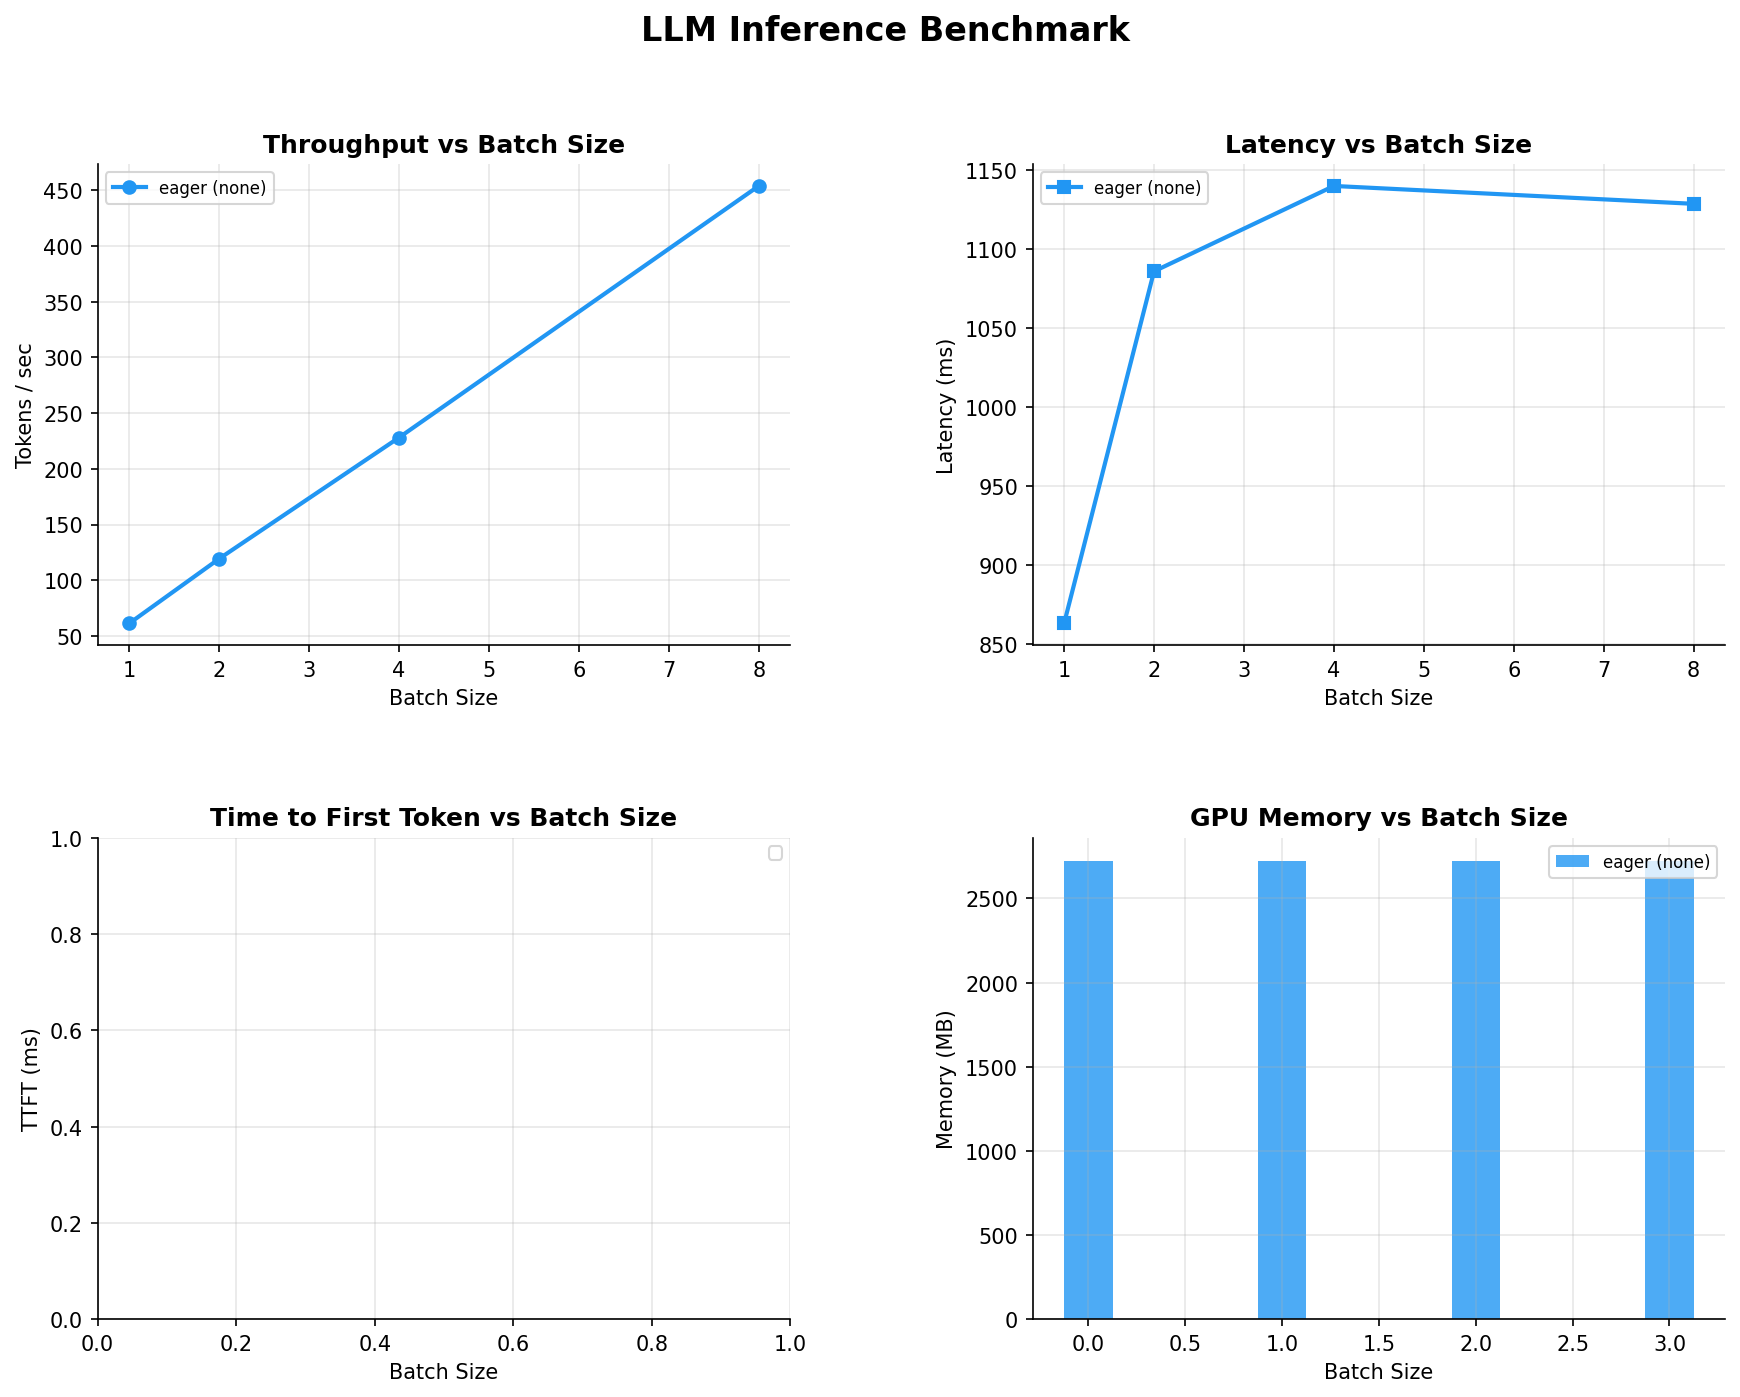

In [10]:
from IPython.display import Image, display
display(Image('/content/bench_readme.png'))

## 5) Backend comparison (README section)
Start with eager + compiled in Colab. vLLM is optional and may not install on all images.

In [11]:
from llminfer.benchmark import BackendComparison
from llminfer.config import Backend

cmp = BackendComparison(
    model_name=MODEL,
    backends=[Backend.EAGER, Backend.COMPILED],
)
cmp_results = cmp.run(batch_sizes=[1, 2, 4, 8], num_runs=3, max_new_tokens=64)
cmp.print_table(cmp_results)
cmp.plot(cmp_results, '/content/comparison_readme.png')

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.decoder.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.decoder.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
W0225 13:26:12.355000 808 torch/_inductor/utils.py:1679] [0/0_1] Not enough SMs to use max_autotune_gemm mode
cudagraph partition due to non gpu ops
cudagraph partition due to non gpu ops
cudagraph partition due to non gpu ops
cudagraph partition due to non gpu ops
cudagraph partition due to non gpu ops
cudagraph partition due to non gpu ops
cudagraph partition due to non gpu ops
cudagraph partition due to non gpu ops
cudagraph partition due to non gpu ops
cudagraph partition due to non gpu ops
cudagraph partition due to non gpu ops
cudagraph partition due to non gpu ops
cudagraph partition due to non gpu ops
cudagraph partition due to non gpu ops
cudagraph partition due to non gpu ops
cudagraph partition due to non g

                 Backend Comparison                  
┏━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┓
┃            ┃ eager ┃  eager ┃ compiled ┃ compiled ┃
┃ Batch Size ┃ Tok/s ┃ Lat ms ┃    Tok/s ┃   Lat ms ┃
┡━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━┩
│          1 │  52.4 │ 1340.4 │     65.3 │    981.9 │
│          2 │ 127.4 │ 1006.3 │    118.2 │   1068.9 │
│          4 │ 228.4 │ 1050.4 │    222.3 │   1148.3 │
│          8 │ 450.8 │ 1137.1 │    415.7 │   1239.2 │
└────────────┴───────┴────────┴──────────┴──────────┘

/content/llminfer/llminfer/benchmark.py:350: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


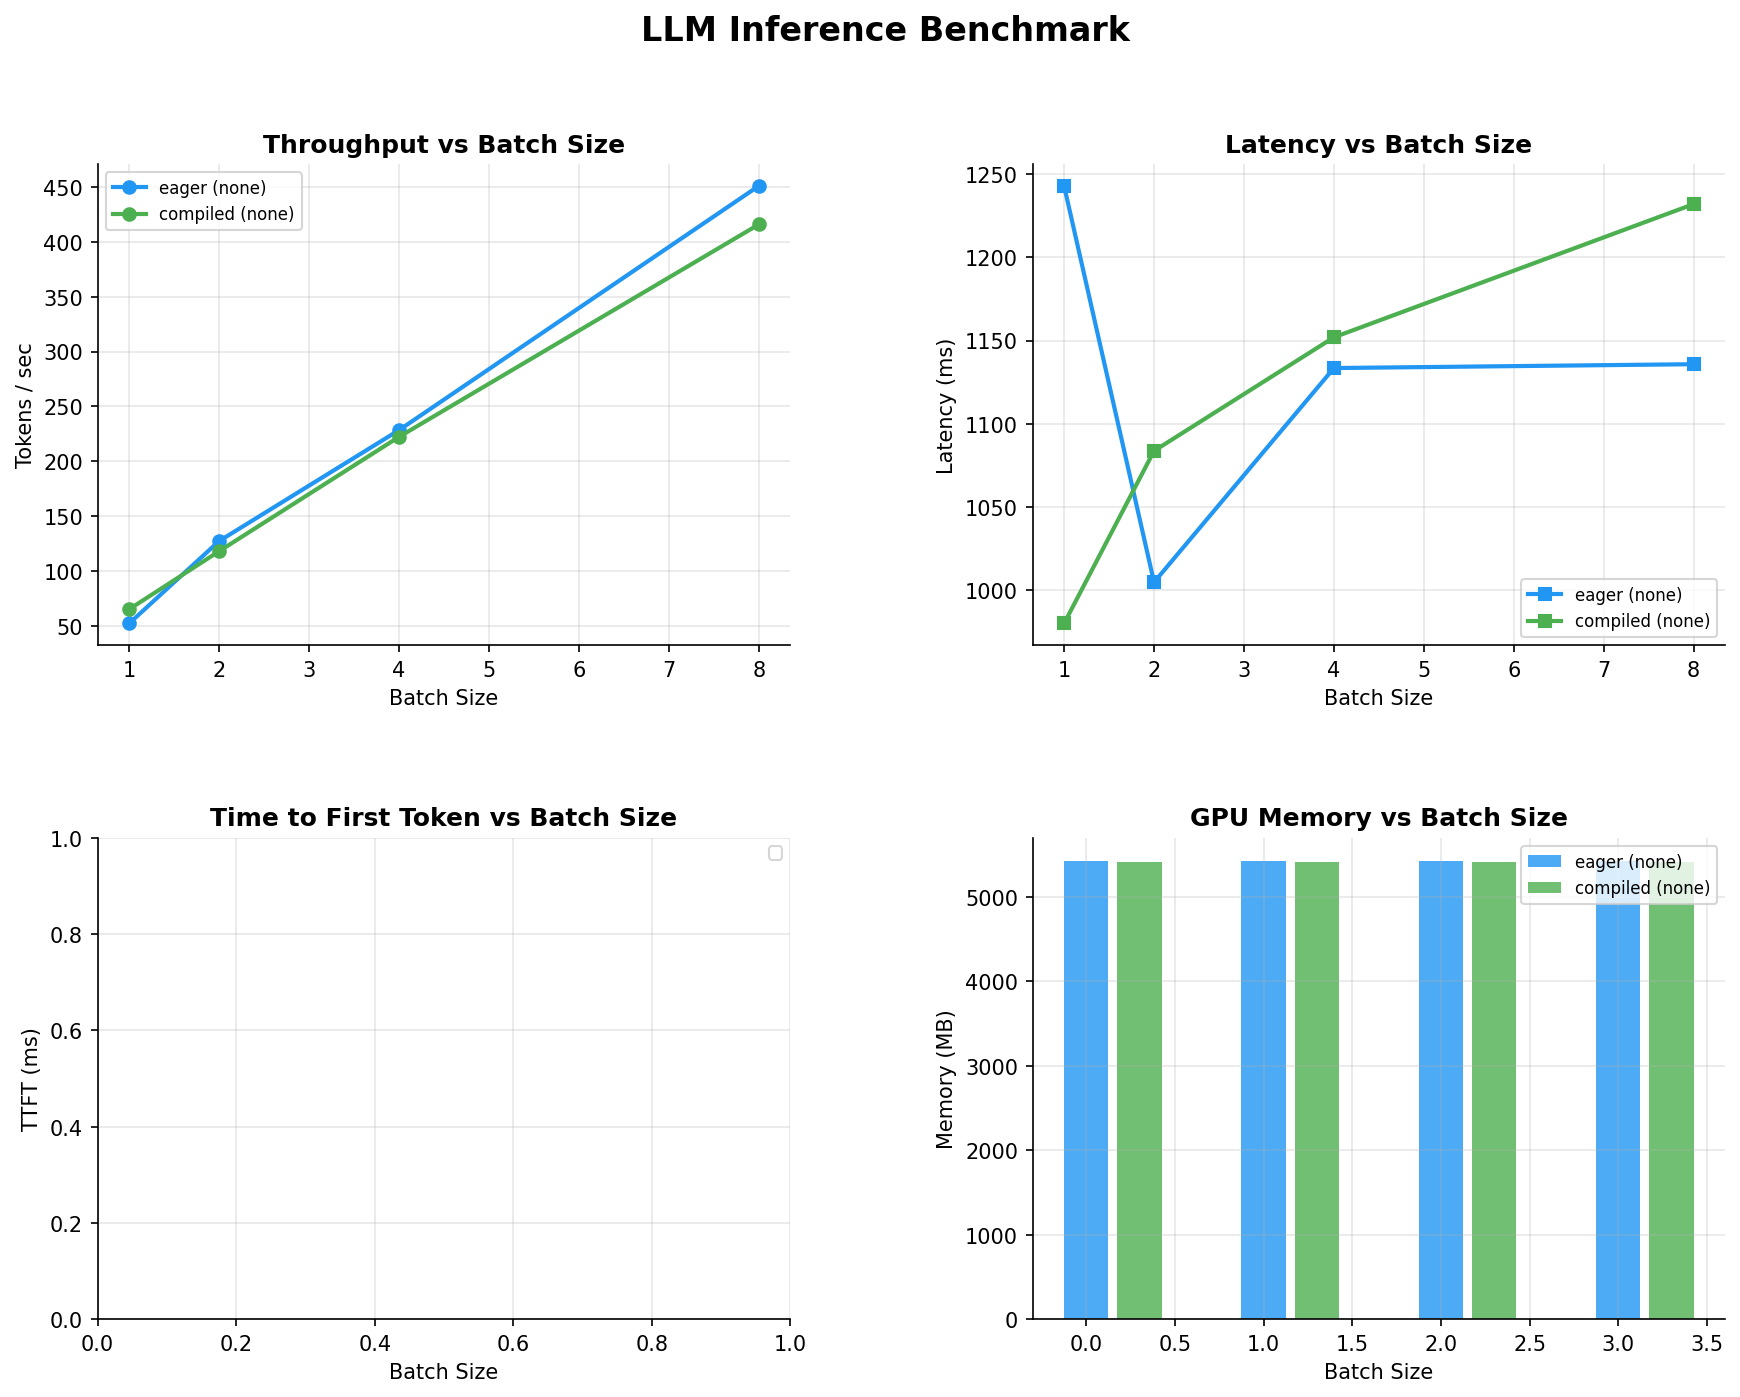

In [12]:
import os
from IPython.display import Image, display

if os.path.exists('/content/comparison_readme.png'):
    display(Image('/content/comparison_readme.png'))
else:
    print('Comparison plot not found.')

### 5.1) Optional vLLM backend
Only run this if your Colab image supports vLLM installation.

In [ ]:
# !pip install -e '.[vllm]'
# from llminfer.config import Backend
# cmp_v = BackendComparison(model_name=MODEL, backends=[Backend.EAGER, Backend.VLLM])
# results_v = cmp_v.run(batch_sizes=[1,2,4], num_runs=3, max_new_tokens=64)
# cmp_v.print_table(results_v)

## 6) CLI commands (README section)

In [13]:
!llminfer stream "Explain backpropagation" --model facebook/opt-125m --quant none --max-tokens 64

config.json: 100% 651/651 [00:00<00:00, 3.23MB/s]
tokenizer_config.json: 100% 685/685 [00:00<00:00, 3.77MB/s]
vocab.json: 899kB [00:00, 36.4MB/s]
merges.txt: 456kB [00:00, 99.9MB/s]
special_tokens_map.json: 100% 441/441 [00:00<00:00, 2.73MB/s]
pytorch_model.bin: 100% 251M/251M [00:01<00:00, 171MB/s]
Loading weights: 100% 197/197 [00:00<00:00, 1282.56it/s, Materializing param=model.decoder.layers.11.self_attn_layer_norm.weight]
The tied weights mapping and config for this model specifies to tie model.decoder.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
generation_config.json: 100% 137/137 [00:00<00:00, 939kB/s]

Streaming:
model.safetensors:   5% 13.4M/251M [00:00<00:10, 22.9MB/s]?
model.safetensors:  18% 45.7M/251M [00:00<00:02, 76.5MB/s]
model.safetensors: 100% 251M/251M [00:01<00:00, 145MB/s]
the same for the majority of Americans. The prob

In [16]:
# Better model for instruction-following on Colab
!llminfer run "Tell me about GPUs in 5 bullet points." \
  --model Qwen/Qwen2.5-1.5B-Instruct \
  --quant nf4 \
  --temp 0.2 \
  --max-tokens 180


Loading weights:   0% 0/338 [00:00<?, ?it/s]
Loading weights:   0% 1/338 [00:00<00:00, 10837.99it/s, Materializing 
param=model.embed_tokens.weight]
Loading weights:   0% 1/338 [00:00<00:00, 424.87it/s, Materializing 
param=model.embed_tokens.weight]  
Loading weights:   1% 2/338 [00:01<03:47,  1.47it/s, Materializing 
param=model.embed_tokens.weight] 
Loading weights:   1% 2/338 [00:01<03:47,  1.47it/s, Materializing 
param=model.layers.0.input_layernorm.weight]
Loading weights:   1% 2/338 [00:01<03:47,  1.47it/s, Materializing 
param=model.layers.0.input_layernorm.weight]
Loading weights:   1% 3/338 [00:01<03:47,  1.47it/s, Materializing 
param=model.layers.0.mlp.down_proj.weight]  
Loading weights:   1% 3/338 [00:01<03:47,  1.47it/s, Materializing 
param=model.layers.0.mlp.down_proj.weight]
Loading weights:   1% 4/338 [00:02<03:45,  1.48it/s, Materializing 
param=model.layers.0.mlp.down_proj.weight]
Loading weights:   1% 4/338 [00:02<03:45,  1.48it/s, Materializing 
param=model.laye

In [17]:
!llminfer bench --model facebook/opt-125m --batch-sizes 1,2,4,8 --runs 5 --plot /content/bench_cli.png --plot-suite-dir /content/bench_cli_plots

Loading weights:   1% 1/197 [00:00<00:00, 3066.01it/s, Materializing param=lm_head.weight]Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
Loading weights: 100% 197/197 [00:00<00:00, 198.36it/s, Materializing param=model.decoder.layers.11.self_attn_layer_norm.weight]
The tied weights mapping and config for this model specifies to tie model.decoder.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
                          Benchmark: facebook/opt-125m                          
┏━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃            ┃    Latency ┃ Latency p95 ┃ Throughput ┃           ┃     GPU Mem ┃
┃ Batch Size ┃   p50 (ms) ┃        (ms) ┃    (tok/s) ┃ TTFT (ms) ┃        (MB) ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━

In [18]:
!llminfer compare --model facebook/opt-125m --backends eager,compiled --plot /content/compare_cli.png --plot-suite-dir /content/compare_cli_plots

Loading weights: 100% 197/197 [00:00<00:00, 895.94it/s, Materializing param=model.decoder.layers.11.self_attn_layer_norm.weight]
The tied weights mapping and config for this model specifies to tie model.decoder.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
Loading weights: 100% 197/197 [00:00<00:00, 954.75it/s, Materializing param=model.decoder.layers.11.self_attn_layer_norm.weight]
The tied weights mapping and config for this model specifies to tie model.decoder.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
W0225 14:11:14.561000 15075 torch/_inductor/utils.py:1679] [0/0_1] Not enough SMs to use max_autotune_gemm mode
cudagraph partition due to non gpu ops
cudagraph partition due to non gpu ops
cudagr

In [19]:
!llminfer info --model facebook/opt-125m --backend compiled

Loading weights: 100% 197/197 [00:00<00:00, 1290.34it/s, Materializing param=model.decoder.layers.11.self_attn_layer_norm.weight]
The tied weights mapping and config for this model specifies to tie model.decoder.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
╭──────────────────────────────── Engine Info ─────────────────────────────────╮
│ {                                                                            │
│     'model': 'facebook/opt-125m',                                            │
│     'backend': 'compiled',                                                   │
│     'quantization': 'none',                                                  │
│     'device': 'cuda',                                                        │
│     'max_batch_size': 8,                                                     │
│     'loaded': True          

In [20]:
%cd /content/llminfer
!python -u examples/full_demo.py

/content/llminfer
INFO  numexpr.utils  NumExpr defaulting to 2 threads.

1. Basic eager inference
INFO  llminfer.backends.eager  Loading model facebook/opt-125m  quant=QuantMode.NONE
INFO  httpx  HTTP Request: HEAD https://huggingface.co/facebook/opt-125m/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO  httpx  HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/opt-125m/27dcfa74d334bc871f3234de431e71c6eeba5dd6/config.json "HTTP/1.1 200 OK"
INFO  httpx  HTTP Request: HEAD https://huggingface.co/facebook/opt-125m/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
INFO  httpx  HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/opt-125m/27dcfa74d334bc871f3234de431e71c6eeba5dd6/tokenizer_config.json "HTTP/1.1 200 OK"
INFO  httpx  HTTP Request: GET https://huggingface.co/api/models/facebook/opt-125m/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
INFO  httpx  HTTP Requ

## 7) Cleanup

In [ ]:
engine.unload()